In [1]:
# the goal of this notebook is to investigate anomalies in spike behavior

In [2]:
import pandas as pd
import plotly.express as px

In [3]:
def extract_state(location_name):

    for state in state_abbrev.keys():
        if state in location_name:
            return state

    return None

In [4]:
# state name (raw dat) to abbreviation (plotly needs) mapping
state_abbrev = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY'
}

# Time Series

I want to look at some of these states separately.

In [5]:
data = 'data/verdant_eye/ve_chatter_by_state_and_date_ice.csv'

tsdf = pd.read_csv(data)
tsdf.columns = ['state', 'date', 'count']
tsdf.head()

,state,date,count
0,Minnesota,2026-05-12,3
1,United States,2026-05-12,19
2,North America,2026-05-12,20
3,Florida,2026-05-12,2
4,Europe,2026-05-12,2


In [6]:
tsdf['state'] = tsdf['state'].apply(extract_state)

tsdf = tsdf.dropna(subset=['state'])

tsdf = (
    tsdf.groupby(['state', 'date'])['count']
    .sum()
    .reset_index()
)

tsdf = tsdf.sort_values('count', ascending=False)

tsdf = tsdf.reset_index(drop=True)
tsdf.head()

,state,date,count
0,Minnesota,2026-01-18,156
1,Minnesota,2026-01-15,149
2,Minnesota,2026-01-24,148
3,Minnesota,2026-01-30,141
4,Minnesota,2026-01-25,140


In [7]:
tsdf.shape

(1789, 3)

In [8]:
pvt_df = pd.pivot_table(tsdf, values='count', index='state', columns='date' ).fillna(0).astype(int)

pvt_df = pvt_df.T
pvt_df.index = pd.to_datetime(pvt_df.index)

pvt_df.head()

state,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,Florida,Georgia,...,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,Wisconsin,Wyoming
date,,,,,,,,,,,,,,,,,,,,,
2026-01-15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-01-16,0,0,2,1,8,1,1,0,6,2,...,0,0,0,10,0,0,0,0,0,0
2026-01-17,0,0,1,0,3,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2026-01-18,0,0,1,0,15,1,0,0,11,0,...,0,0,0,5,1,0,5,2,3,0
2026-01-19,1,0,0,0,8,1,0,0,3,0,...,0,0,0,13,0,0,0,0,0,0


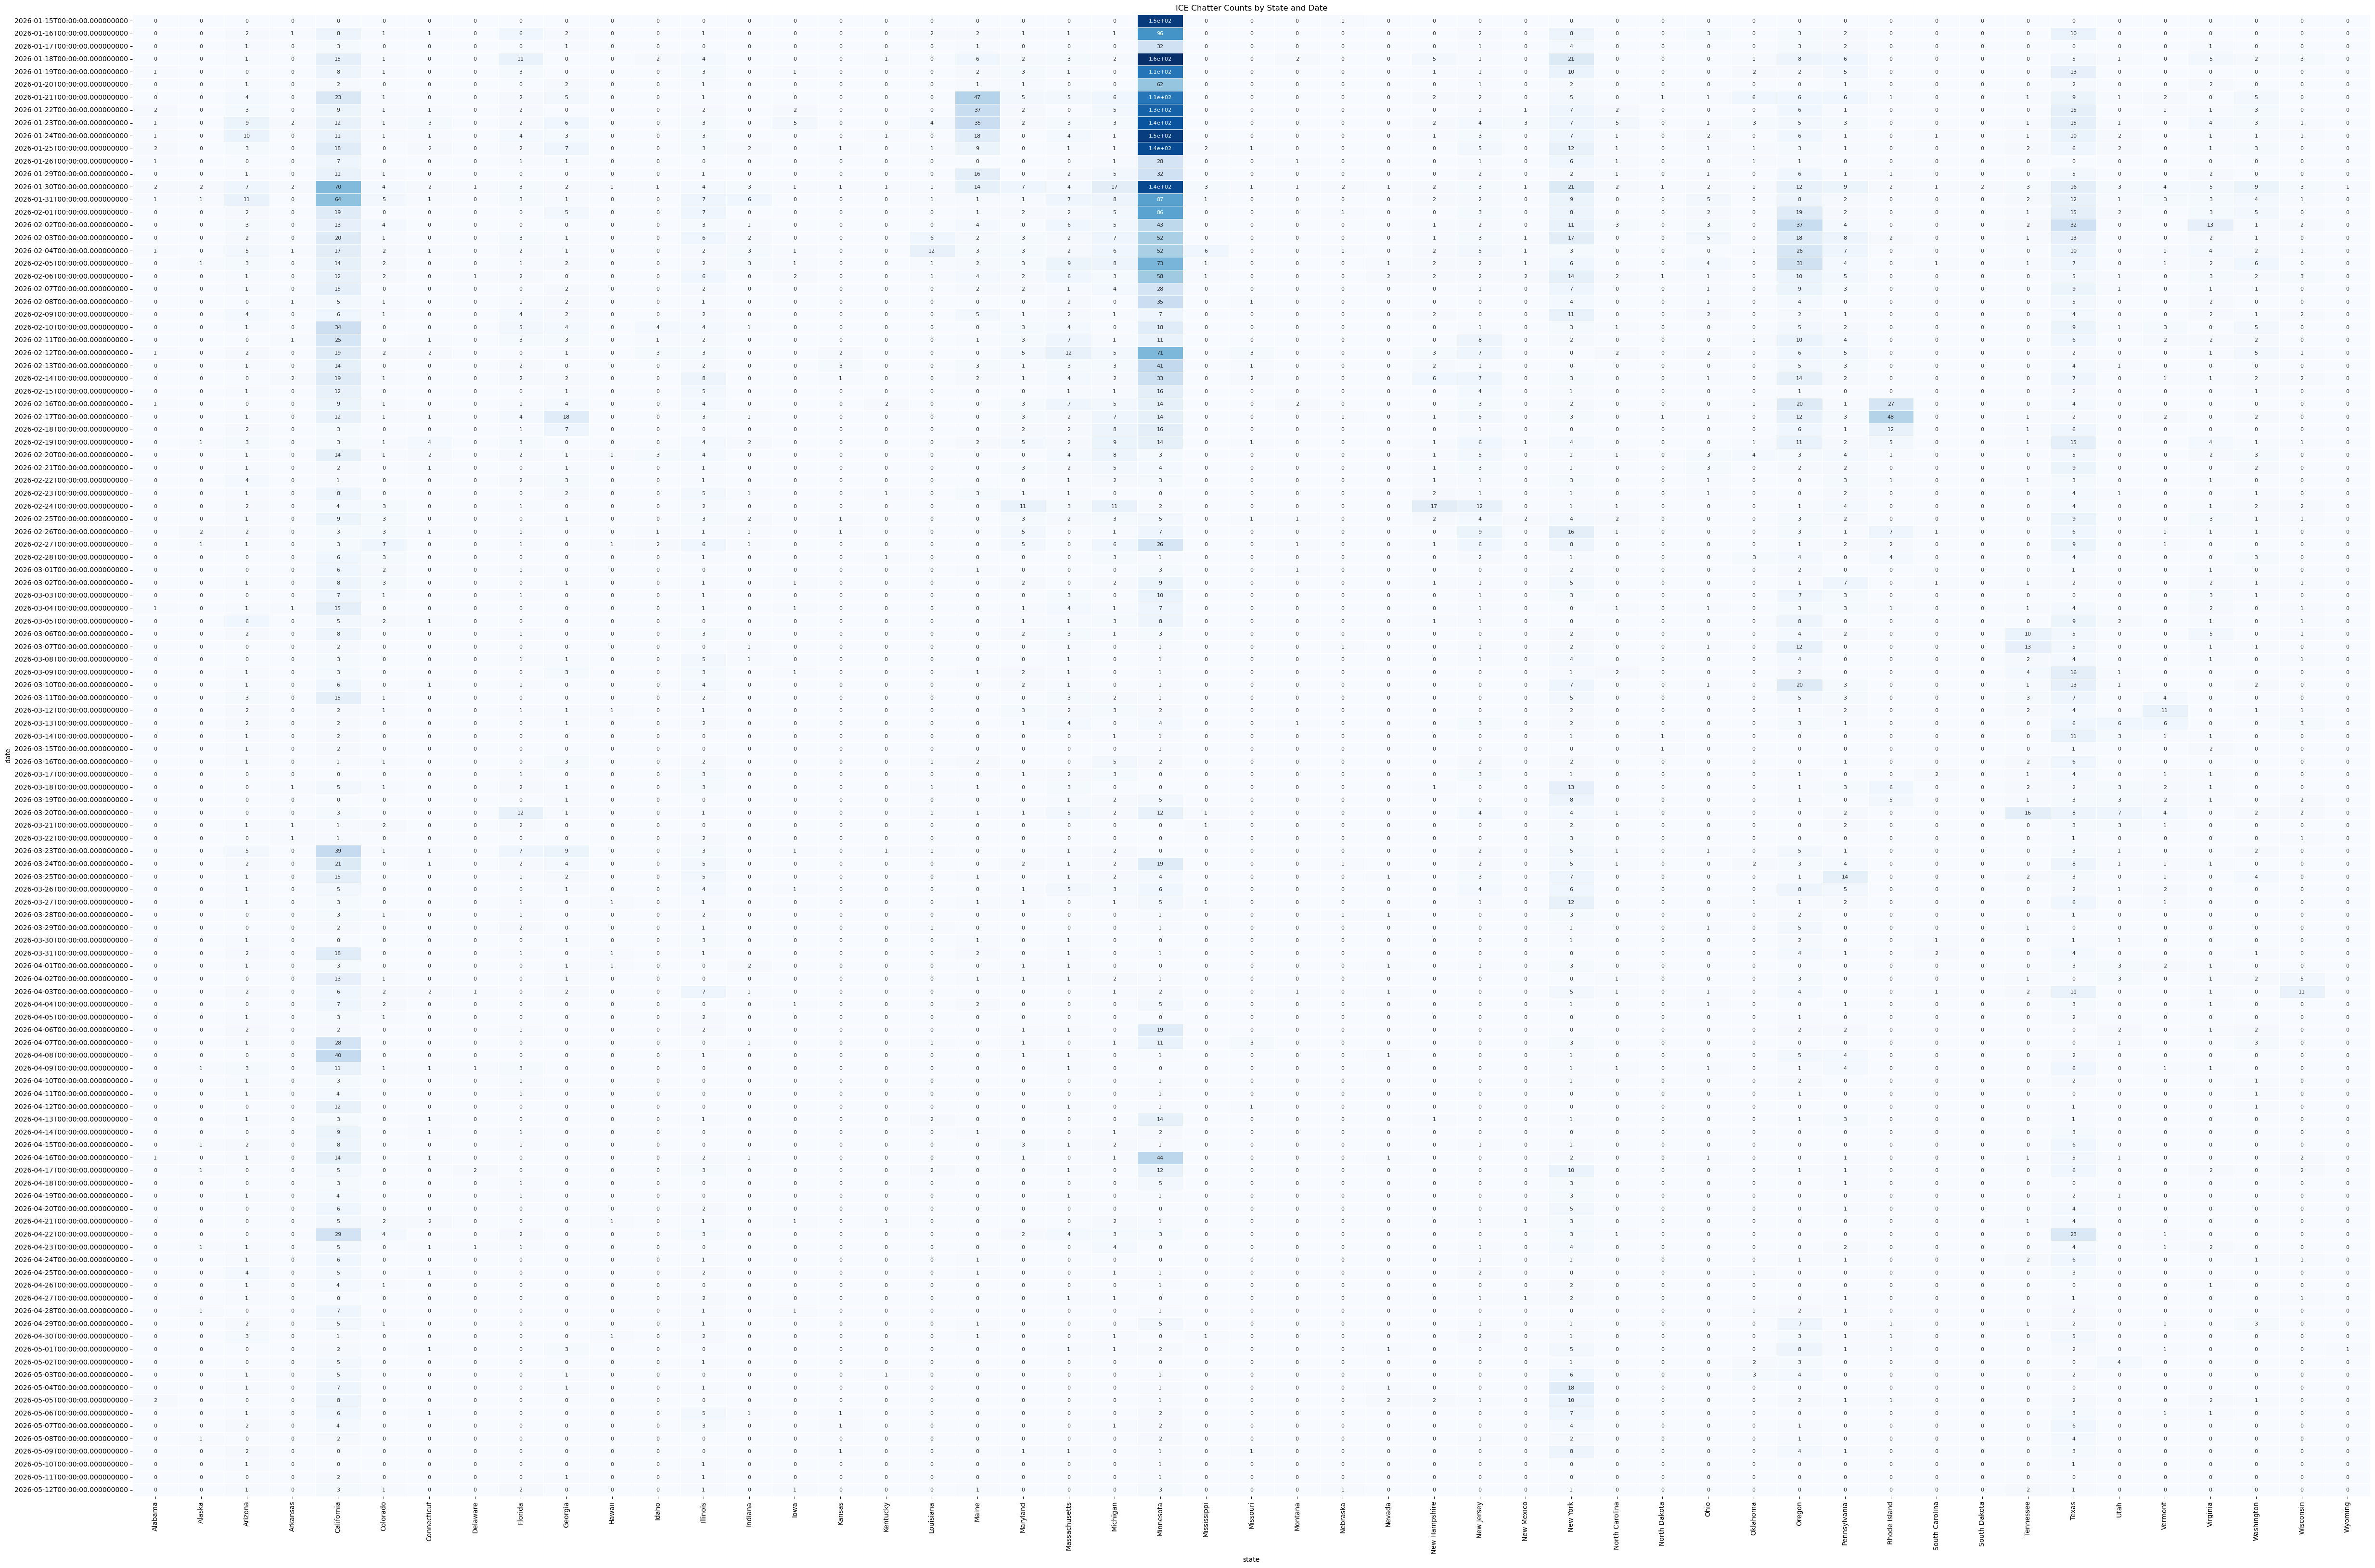

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(60, 40))
sns.heatmap(pvt_df, annot=True, cmap='Blues', linewidths=0.5, cbar=False, annot_kws={"size": 8})
plt.title('ICE Chatter Counts by State and Date')
plt.show()

# wanted to try seaborn approach from https://100daysofnetworks.substack.com/p/day-39-of-100daysofnetworks
# not interactive, less useful, but visually useful

# Today's Investigation Questions

- Can we capture the spikes using Anomaly Detection (Isolation Forests, etc)? (today)
- Do the states correlate with other states? (another day)
- Can we predict when they are going to happen before they happen? (another day)

Done
- What are the spikes? (yesterday)

In [10]:
pvt_df.head()

state,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,Florida,Georgia,...,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,Wisconsin,Wyoming
date,,,,,,,,,,,,,,,,,,,,,
2026-01-15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-01-16,0,0,2,1,8,1,1,0,6,2,...,0,0,0,10,0,0,0,0,0,0
2026-01-17,0,0,1,0,3,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2026-01-18,0,0,1,0,15,1,0,0,11,0,...,0,0,0,5,1,0,5,2,3,0
2026-01-19,1,0,0,0,8,1,0,0,3,0,...,0,0,0,13,0,0,0,0,0,0


<Axes: xlabel='date'>

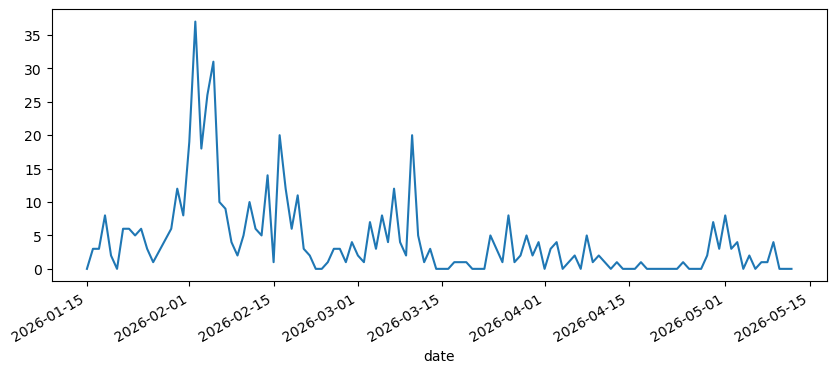

In [11]:
pvt_df['Oregon'].plot(figsize=(10,4))

<Axes: xlabel='date'>

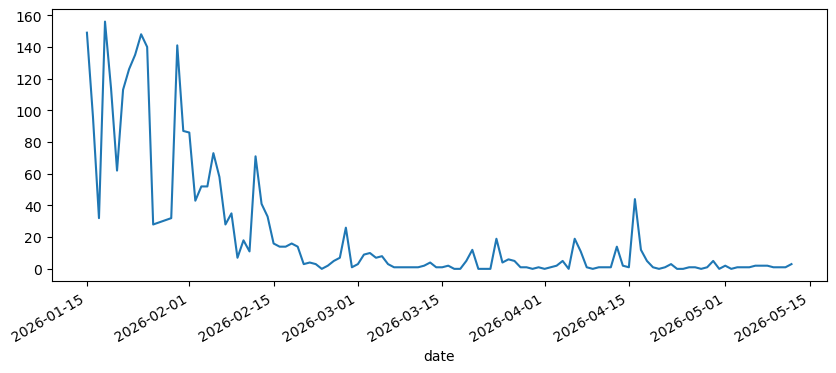

In [12]:
pvt_df['Minnesota'].plot(figsize=(10,4))

<Axes: xlabel='date'>

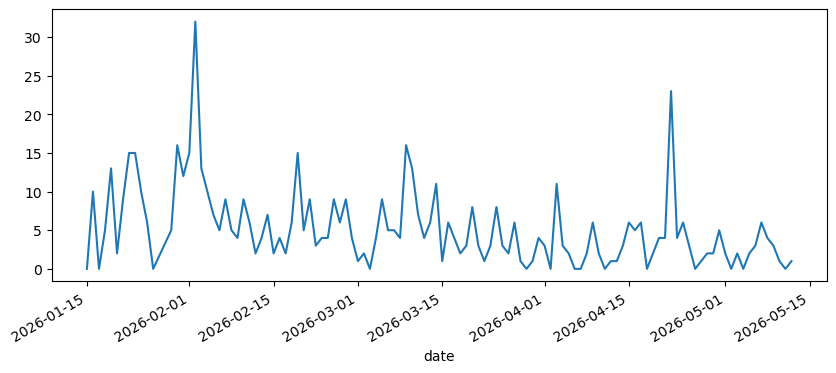

In [13]:
pvt_df['Texas'].plot(figsize=(10,4))

# Isolation Forests: Individual States

We can use this for Anomaly Detection. I learned about this a long time ago. Read the documentation. I'm not teaching beginner articles anymore. I show how things can be used.

Let's use Isolation Forests with default values and look at individual states separately.

In [14]:
from sklearn.ensemble import IsolationForest

def draw_anomalies(state, contamination=0.1):

    model = IsolationForest(contamination=contamination, random_state=1337)
    preds = model.fit_predict(pvt_df[[state]])
    anoms = pvt_df[preds == -1]
    ax = pvt_df[state].plot(figsize=(10, 4), title='{} ICE Spike Anomalies'.format(state))
    ax.plot(anoms.index, anoms[state], "ro")

    plt.show()
    
# idea: what if we fit on state medians instead of one state? ( wasn't a great idea; was an idea :p )
# the above function was created by claude. it is useful for visualization if you have the data ready

In [15]:
# truly I have had enough of AI "making me faster". It does not. I'm going to have to 
# do this myself. Claude is crap at Data Science. People who think it is a good coder are wrong.

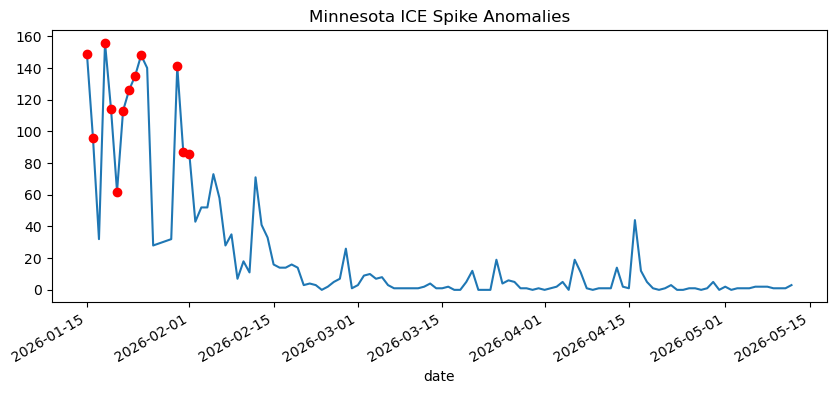

In [16]:
draw_anomalies('Minnesota', 0.1)

# the 0.1 caused the high numbers from January to dwarf everything after; this is not sensitive enough

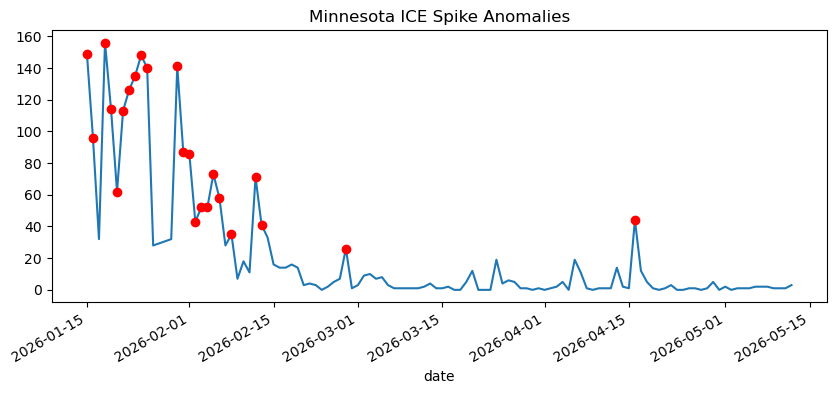

In [17]:
draw_anomalies('Minnesota', 0.2)

# the 0.2 does better

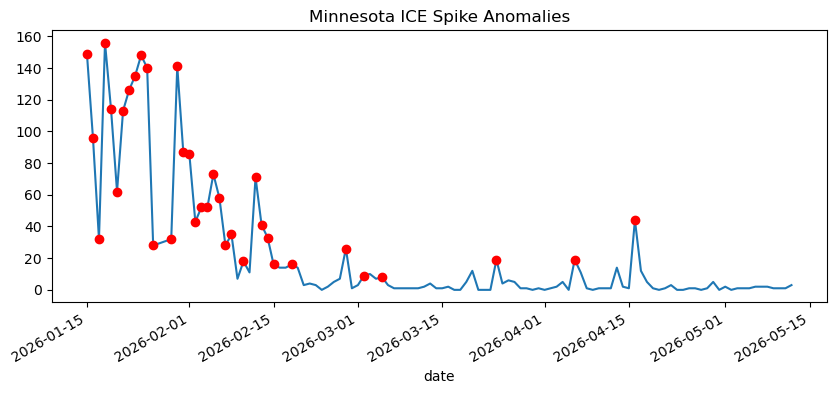

In [18]:
draw_anomalies('Minnesota', 0.3)

# the 0.3 looks great, but I wonder how it will affect other states.

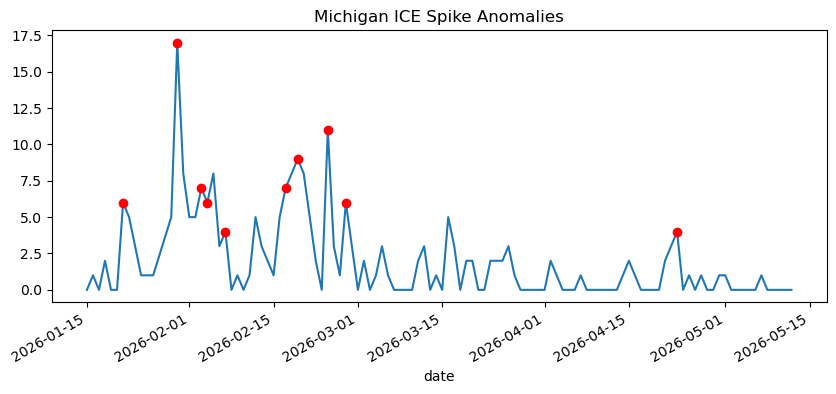

In [19]:
draw_anomalies('Michigan')

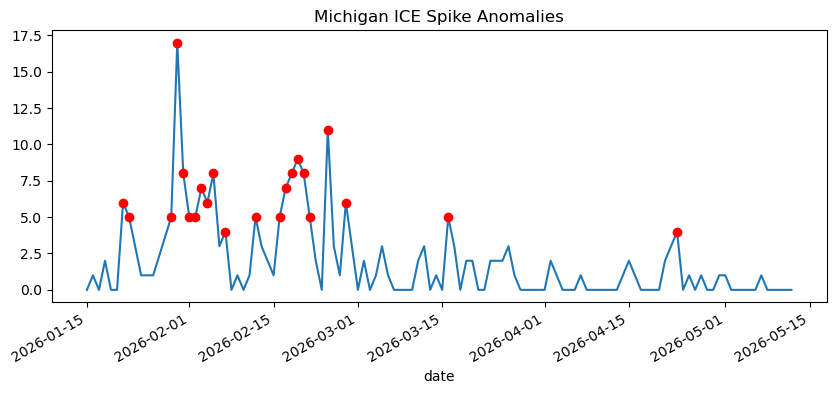

In [20]:
draw_anomalies('Michigan', 0.2)

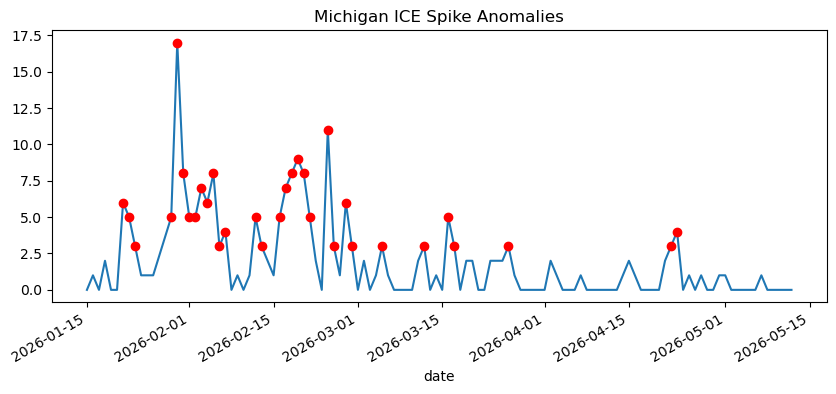

In [21]:
draw_anomalies('Michigan', 0.3)

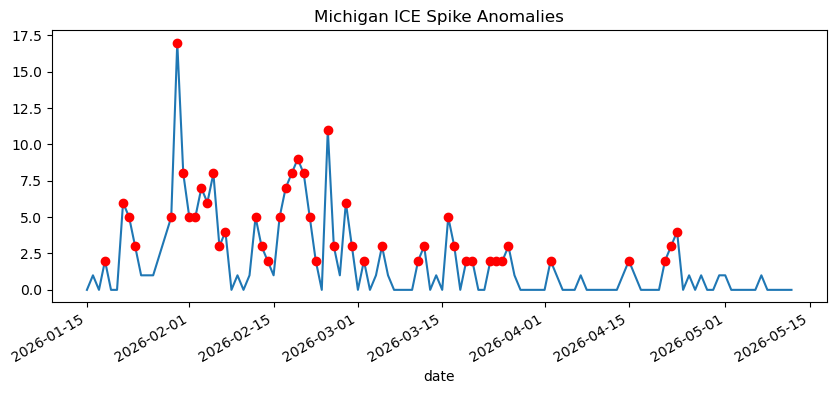

In [22]:
draw_anomalies('Michigan', 0.4)

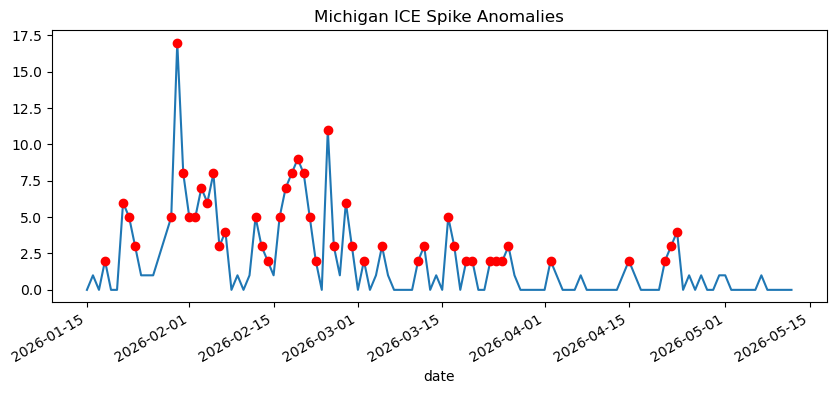

In [23]:
draw_anomalies('Michigan', 0.5)

In [25]:
pvt_df[['Michigan']].describe()

state,Michigan
count,116.000000
mean,1.948276
std,2.809440
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,17.000000


# Isolation Forests: All 50 States

Next, let's try to identify anomalies across all states at the same time, using their collective numbers to tune each other.

In [26]:
from sklearn.ensemble import IsolationForest

def draw_anomalies_all_states(pvt_df):

    states = list(pvt_df.columns)

    fig, axes = plt.subplots(10, 5, figsize=(20, 30))
    axes = axes.flatten()

    for i, state in enumerate(states):
        model = IsolationForest(contamination=0.2, random_state=1337)
        preds = model.fit_predict(pvt_df[[state]])
        anoms = pvt_df[preds == -1]
        ax = axes[i]
        pvt_df[state].plot(ax=ax, title=state)
        ax.plot(anoms.index, anoms[state], "ro")

    plt.tight_layout()
    plt.show()

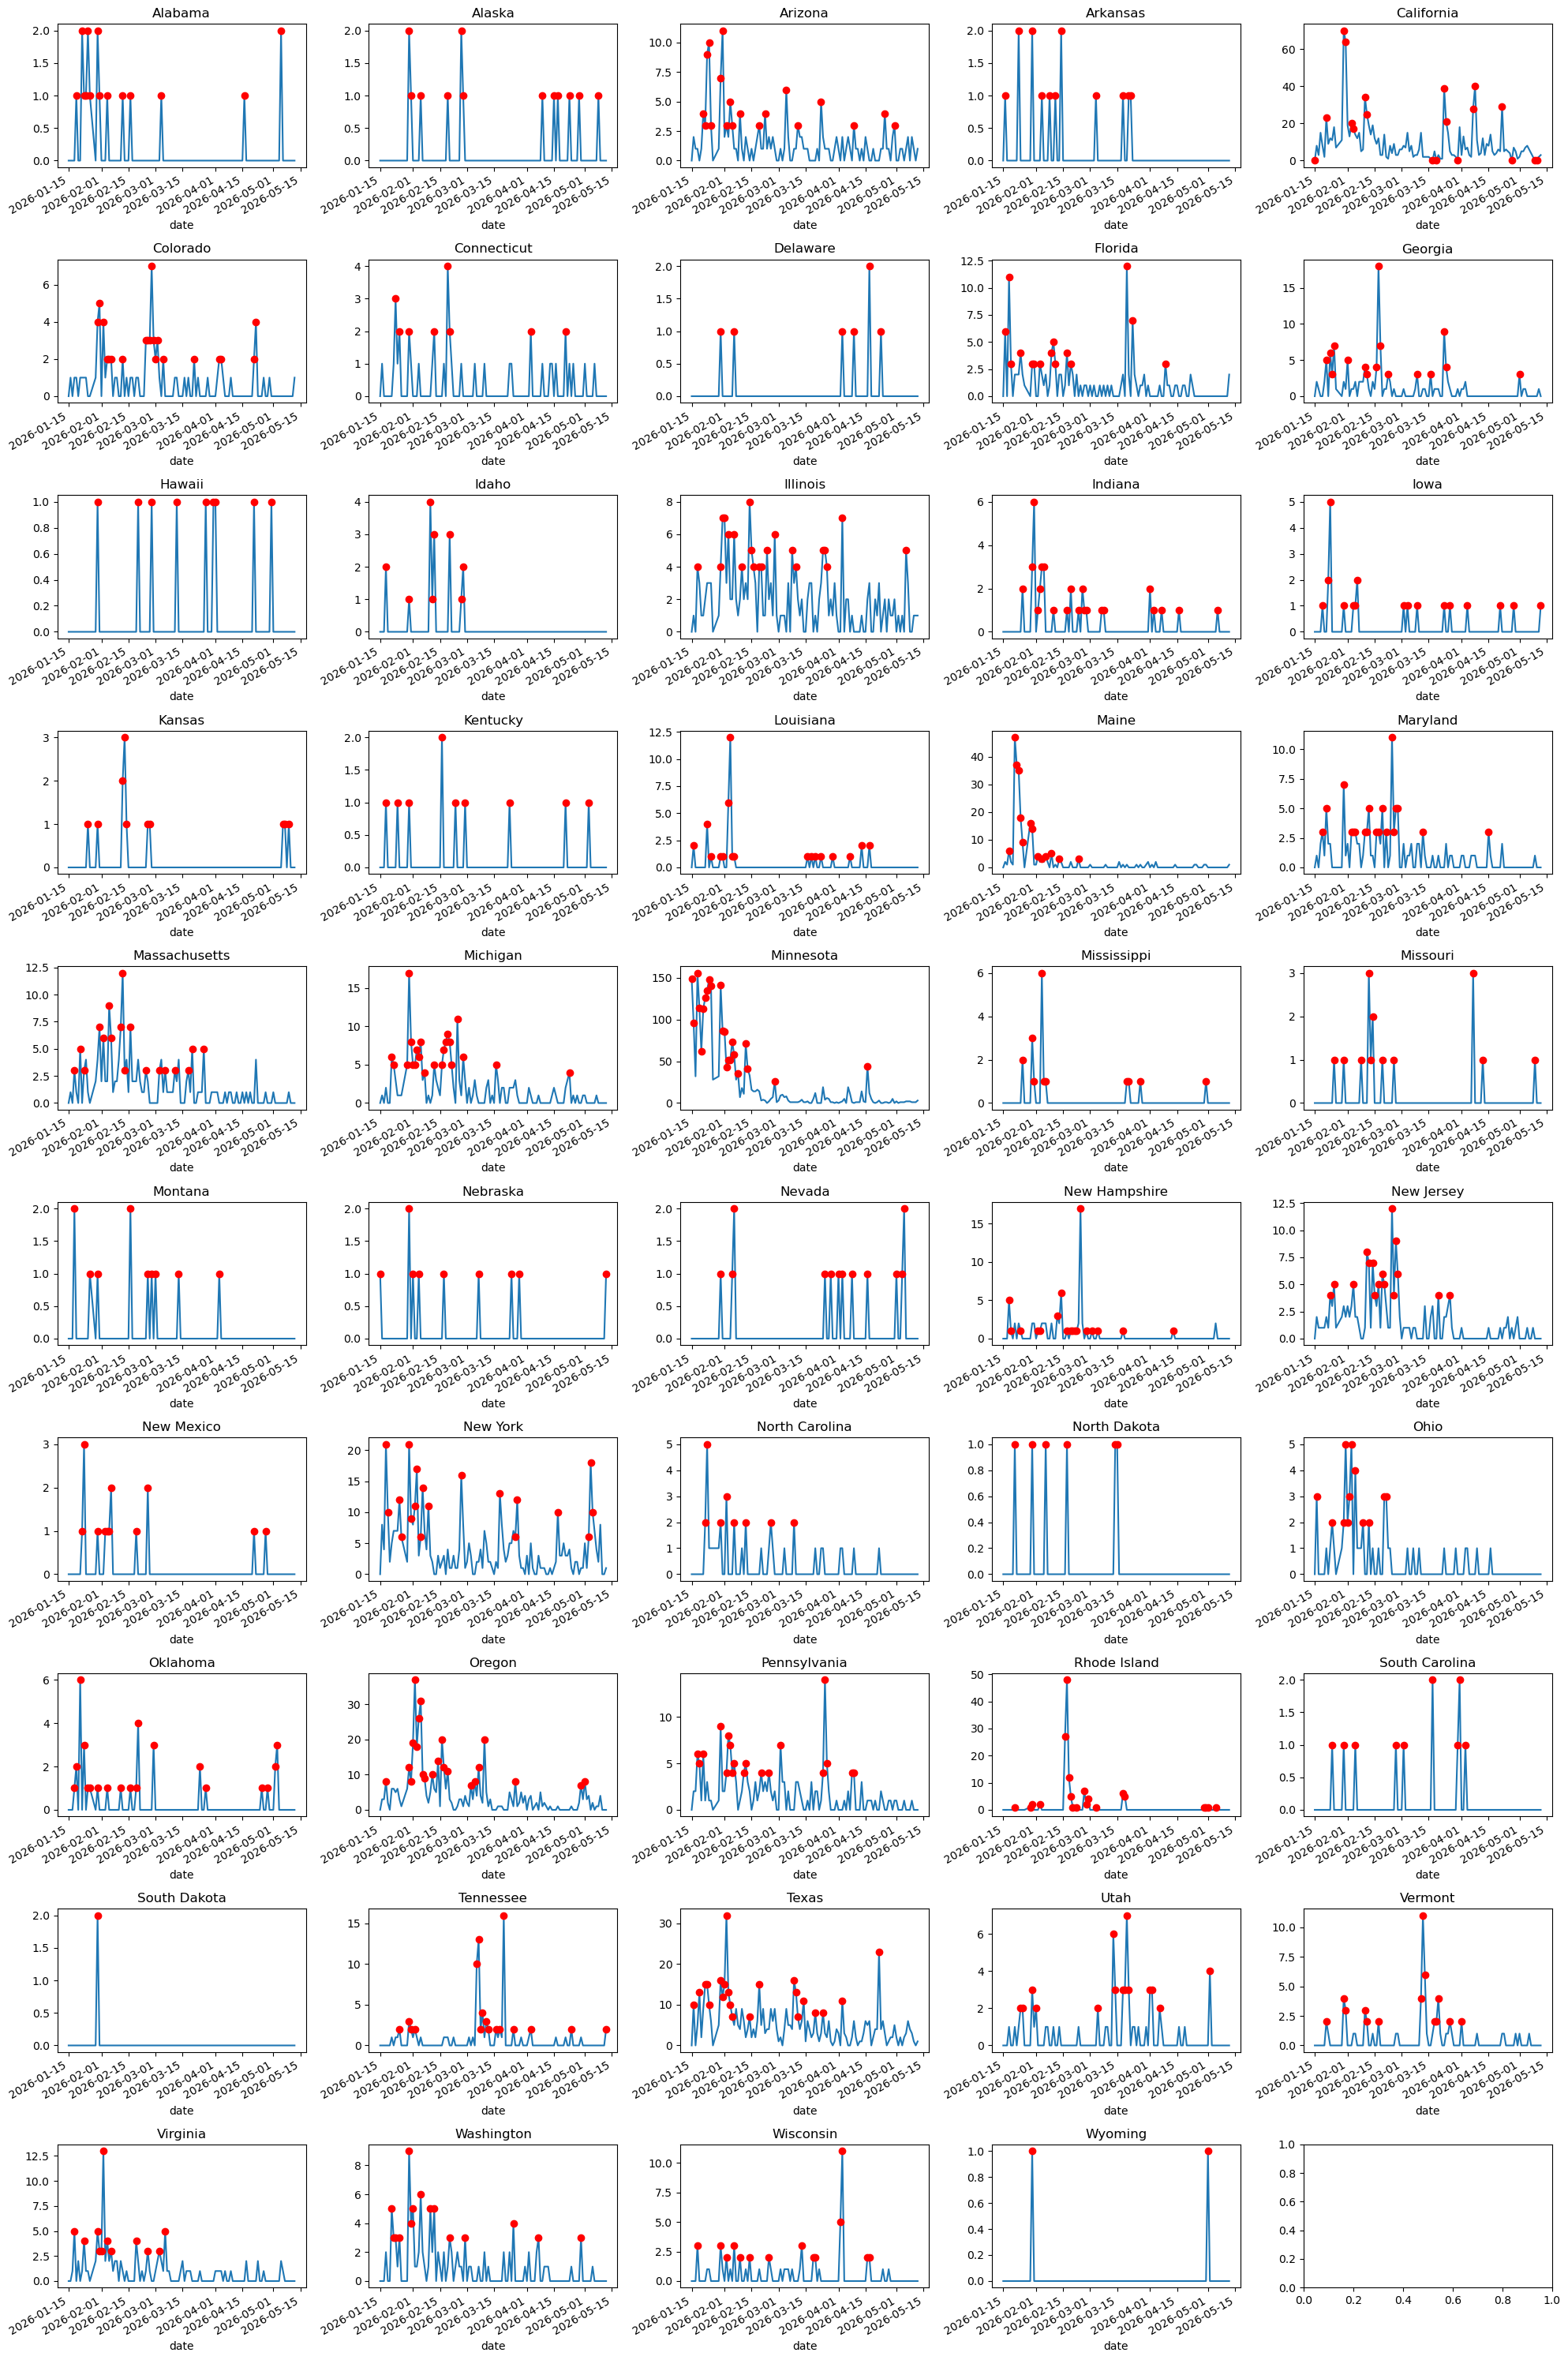

In [27]:
draw_anomalies_all_states(pvt_df)

# That is "Data Science Trash"

I let Claude make that visualization, and I just went with it because I could see that it was producing what I call Data Science Trash. Visualizations that look neat but are practically useless. We are going to work on building something that is a) sensitive to time and b) not a stupid grid of squares. 

Lesson learned, I am going to do Data Science from hand. I wanted to see how well Claude could keep up with me but it cannot. It wasted so much of my time and energy and destroyed my good mood. I do not recommend using AI for anything data related. Many of you can't even tell if it is producing good code because the fundamentals are missing.


# Anomaly Detection Across 50 States (Better UX)
The goal is to create something helpful. I don't even mind if it is just something I read. Flashy is BS most of the time.

Edit: I was originally planning on using Machine Learning for this, but simpler approaches are... simpler. :) I am no longer detecting anomolies, I am coloring behavior. I think that is more interesting as it shows the shape of situations.

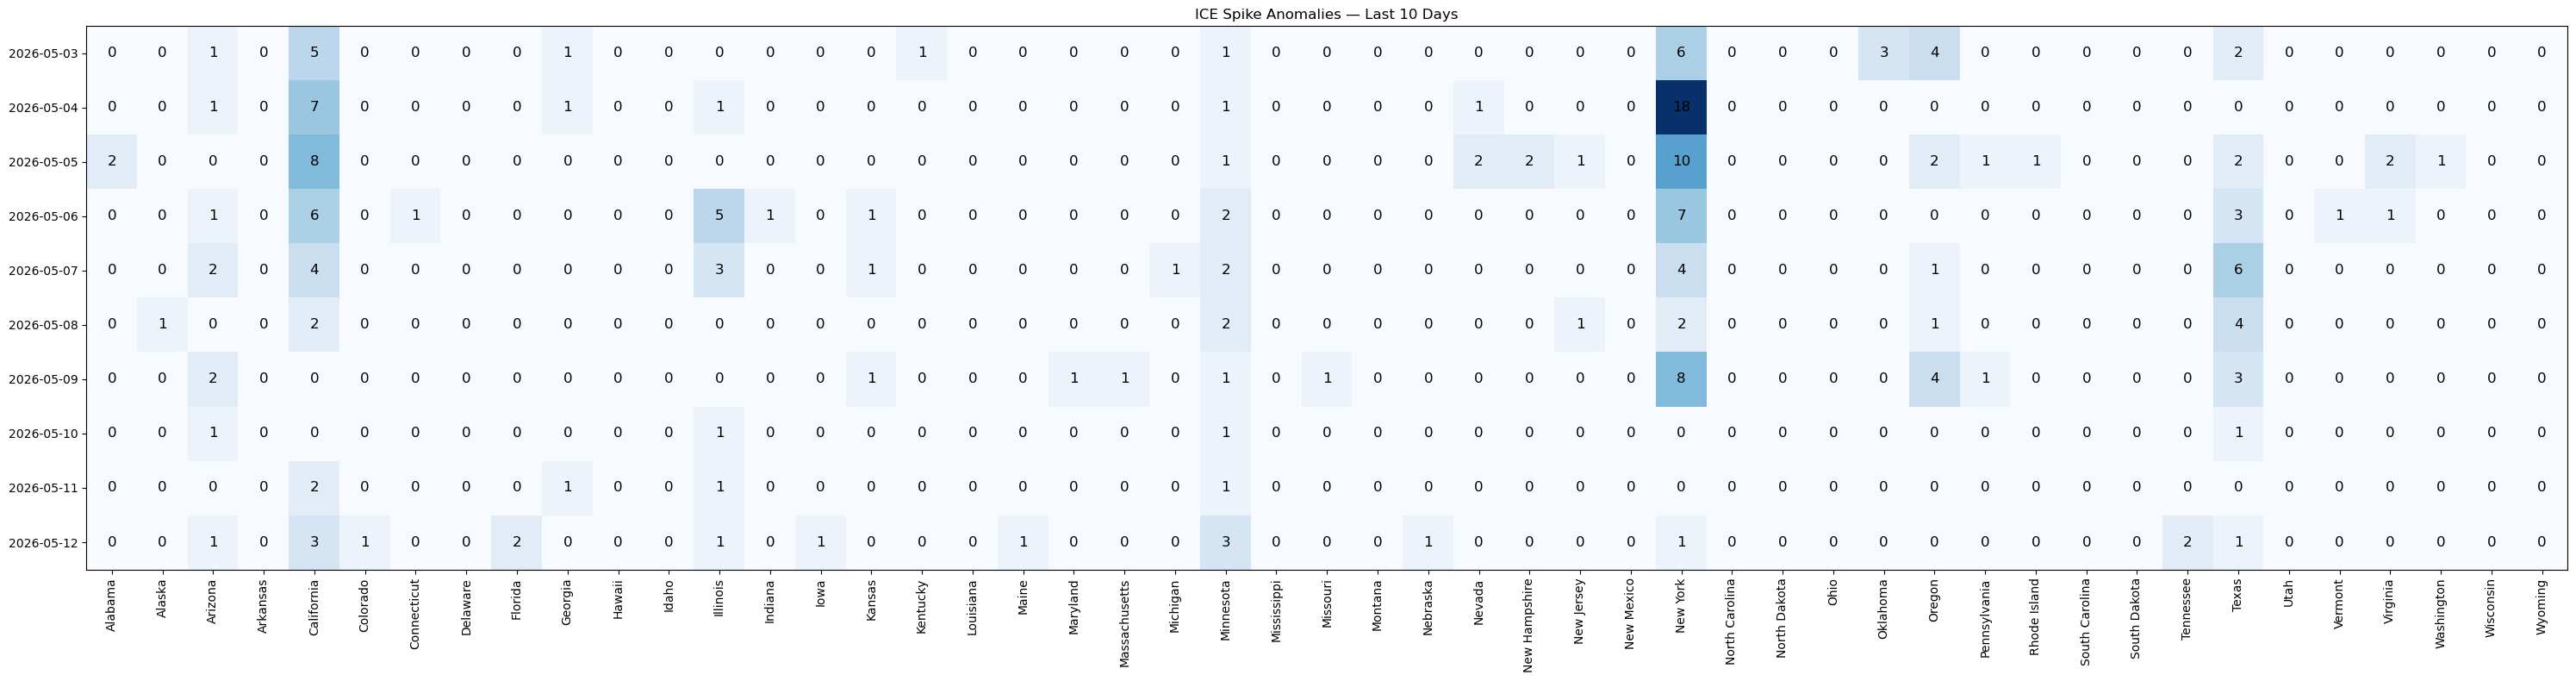

In [28]:
window = pvt_df.tail(10)

fig, ax = plt.subplots(figsize=(30, 8))
fig.patch.set_facecolor("white")

ax.imshow(window.values, aspect="auto", cmap="Blues")

for row in range(window.shape[0]):
    for col in range(window.shape[1]):
        ax.text(col, row, str(window.values[row, col]), ha="center", va="center", fontsize=12, color="black")

ax.set_xticks(range(len(window.columns)))
ax.set_xticklabels(window.columns, rotation=90)
ax.set_yticks(range(len(window)))
ax.set_yticklabels([str(d.date()) for d in window.index])
ax.set_title("ICE Spike Anomalies — Last 10 Days")

plt.tight_layout()
plt.show()

# this is a great foundation. i will go from here. this is closer to what i want, but I want rolling window and alive

The above graphs are useless to me, and I don't need anomoly detection for this. I just wanted to show it off so that you all have another option for easily tagging spikes. I want something more useful than a spike detector, so I will build something practical. 

AI always wants to give a function that does the whole thing instead of refactoring cleanly. I will first split this function into two functions: data work, then visualization.

In [29]:
window_dfs = [pvt_df.iloc[i:i+14] for i in range(0, len(pvt_df), 14)]
window_dfs[0].head()

state,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,Florida,Georgia,...,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,Wisconsin,Wyoming
date,,,,,,,,,,,,,,,,,,,,,
2026-01-15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-01-16,0,0,2,1,8,1,1,0,6,2,...,0,0,0,10,0,0,0,0,0,0
2026-01-17,0,0,1,0,3,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2026-01-18,0,0,1,0,15,1,0,0,11,0,...,0,0,0,5,1,0,5,2,3,0
2026-01-19,1,0,0,0,8,1,0,0,3,0,...,0,0,0,13,0,0,0,0,0,0


In [30]:
def draw_slice_heatmap(window, start, end):

    active_cols = window.columns[window.sum() > 0]
    window = window[active_cols]

    fig, ax = plt.subplots(figsize=(20, 5))
    fig.patch.set_facecolor("white")
    ax.imshow(window.values, aspect="auto", cmap="Blues")
    for row in range(window.shape[0]):
        for col in range(window.shape[1]):
            ax.text(col, row, str(window.values[row, col]), ha="center", va="center", fontsize=7, color="black")
    ax.set_xticks(range(len(window.columns)))
    ax.set_xticklabels(window.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(window)))
    ax.set_yticklabels([str(d.date()) for d in window.index], fontsize=7)
    ax.set_title("ICE Spike Heatmap — {} to {}".format(start, end), fontsize=9)
    plt.tight_layout()
    plt.show()


def draw_slice_totals(window, start, end, totals, medians):

    active_totals = totals[totals > 0]
    active_medians = medians[active_totals.index]
    inactive_states = sorted(totals[totals == 0].index.tolist())

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor("white")
    ax.bar(active_totals.index, active_totals.values, color="#4a90d9", width=0.6)
    ax.scatter(active_totals.index, active_medians.values, color="black", zorder=5, s=20)
    ax.set_title("State Totals — {} to {}".format(start, end), fontsize=9)
    ax.set_xticks(range(len(active_totals)))
    ax.set_xticklabels(active_totals.index, rotation=90, fontsize=7)
    ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    if inactive_states:
        print("No activity: {}".format(", ".join(inactive_states)))


def render_slice_report(window_df):

    window = window_df
    start = window.index[0].date()
    end = window.index[-1].date()
    totals = window.sum().sort_values(ascending=False)
    medians = window.median()

    print("Date Window: {} — {}".format(start, end))
    draw_slice_heatmap(window, start, end)
    draw_slice_totals(window, start, end, totals, medians)
    
# AI is useful for visualization. I do not trust it for data operations or code in general.

Date Window: 2026-04-25 — 2026-05-08


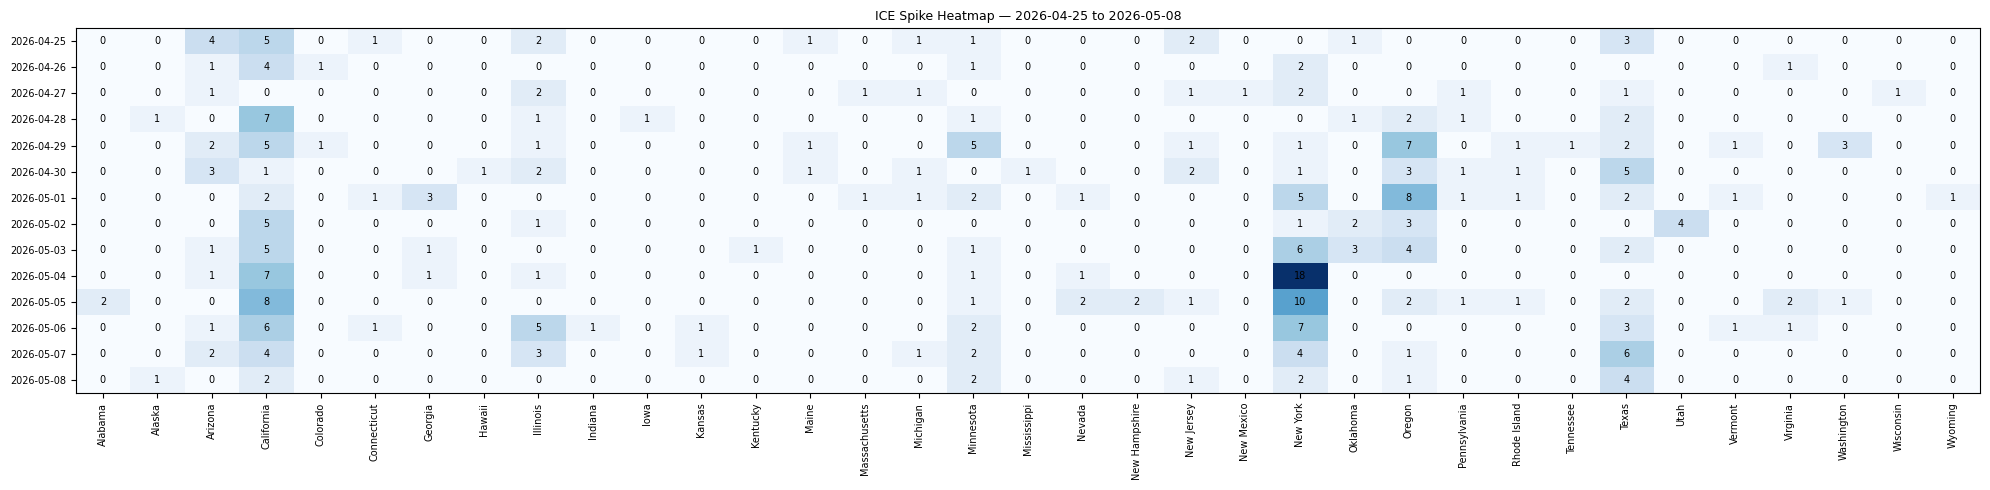

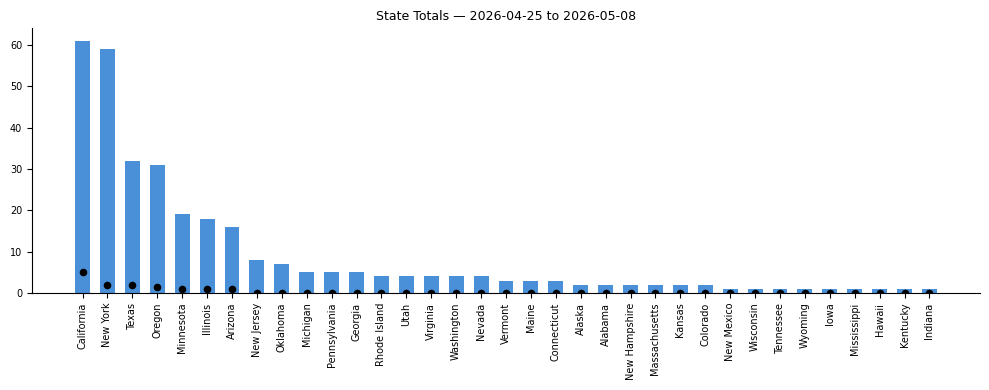

No activity: Arkansas, Delaware, Florida, Idaho, Louisiana, Maryland, Missouri, Montana, Nebraska, North Carolina, North Dakota, Ohio, South Carolina, South Dakota


In [31]:
render_slice_report(window_dfs[7])

Cool. This is a decent foundation. The trick was splitting the data work from the visualization work, which is 101 stuff to anyone who has worked in data. After that, create and refactor code. AI will try to create one function that does everything. Force it to create the functions you need. Do not trust it.

# Rolling Report

Date Window: 2026-01-15 — 2026-01-30


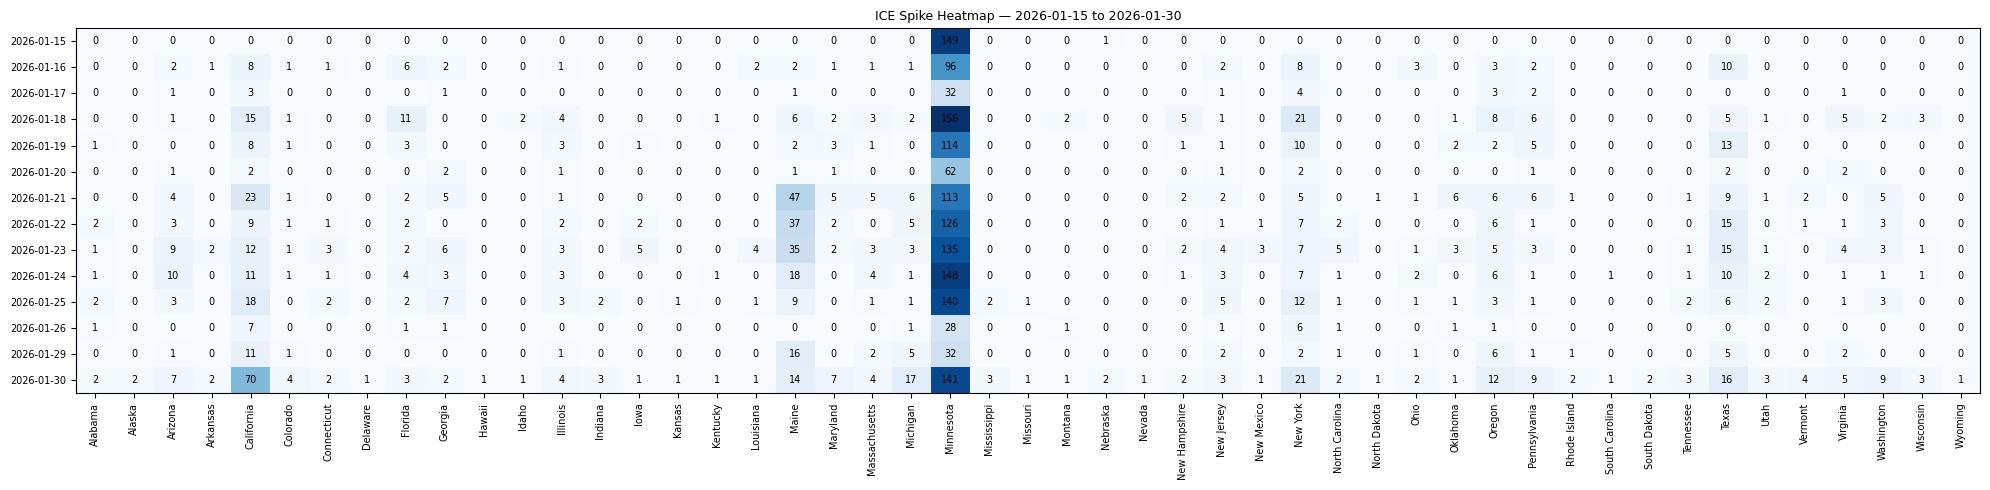

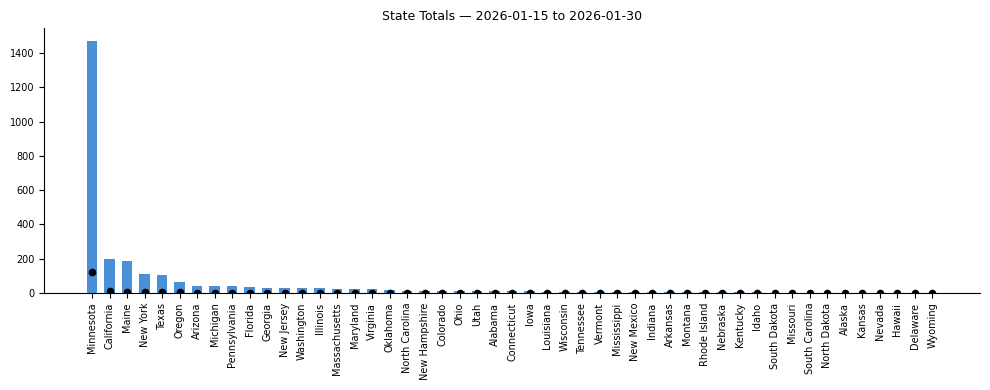


Date Window: 2026-01-31 — 2026-02-13


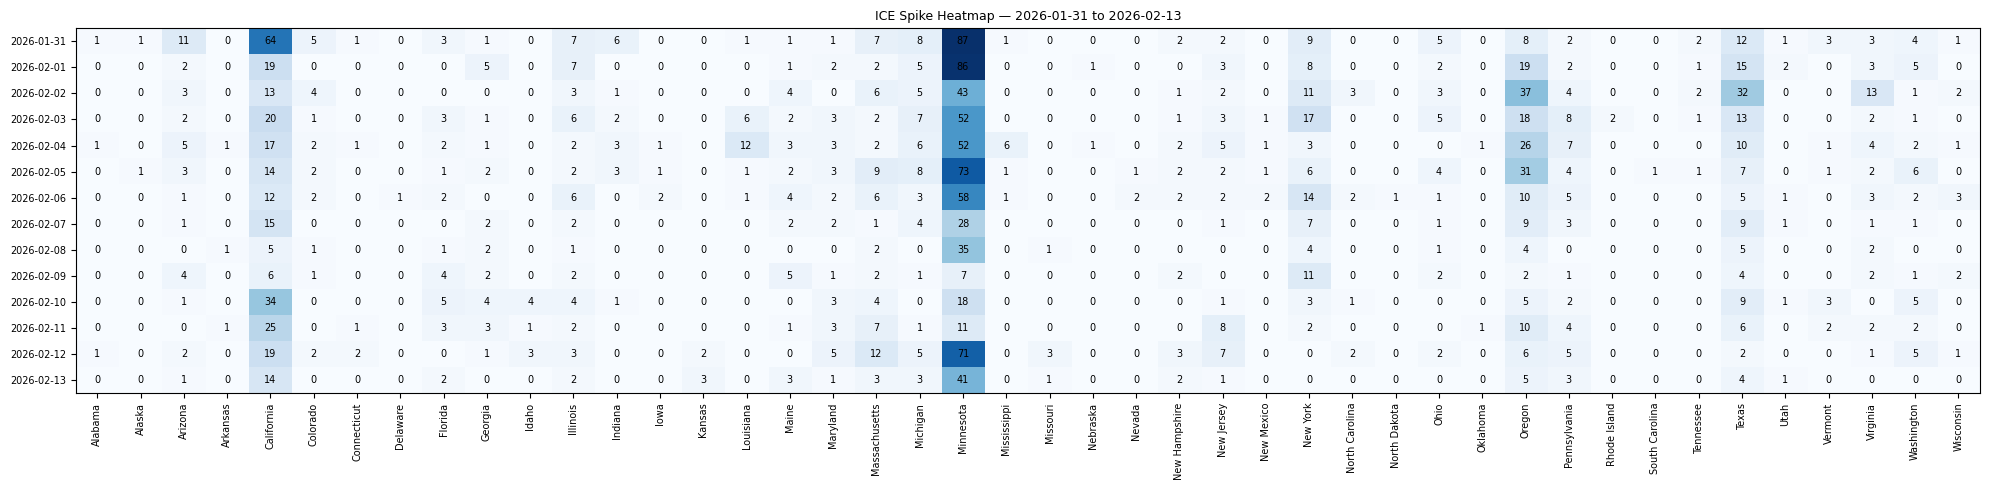

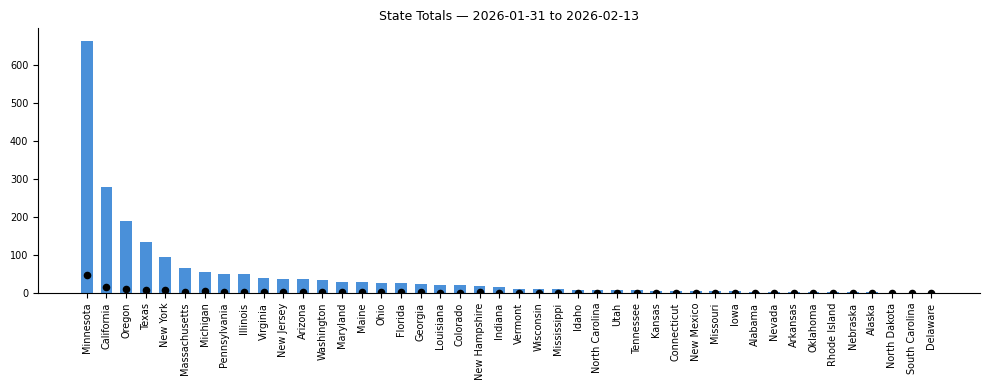

No activity: Hawaii, Kentucky, Montana, South Dakota, Wyoming

Date Window: 2026-02-14 — 2026-02-27


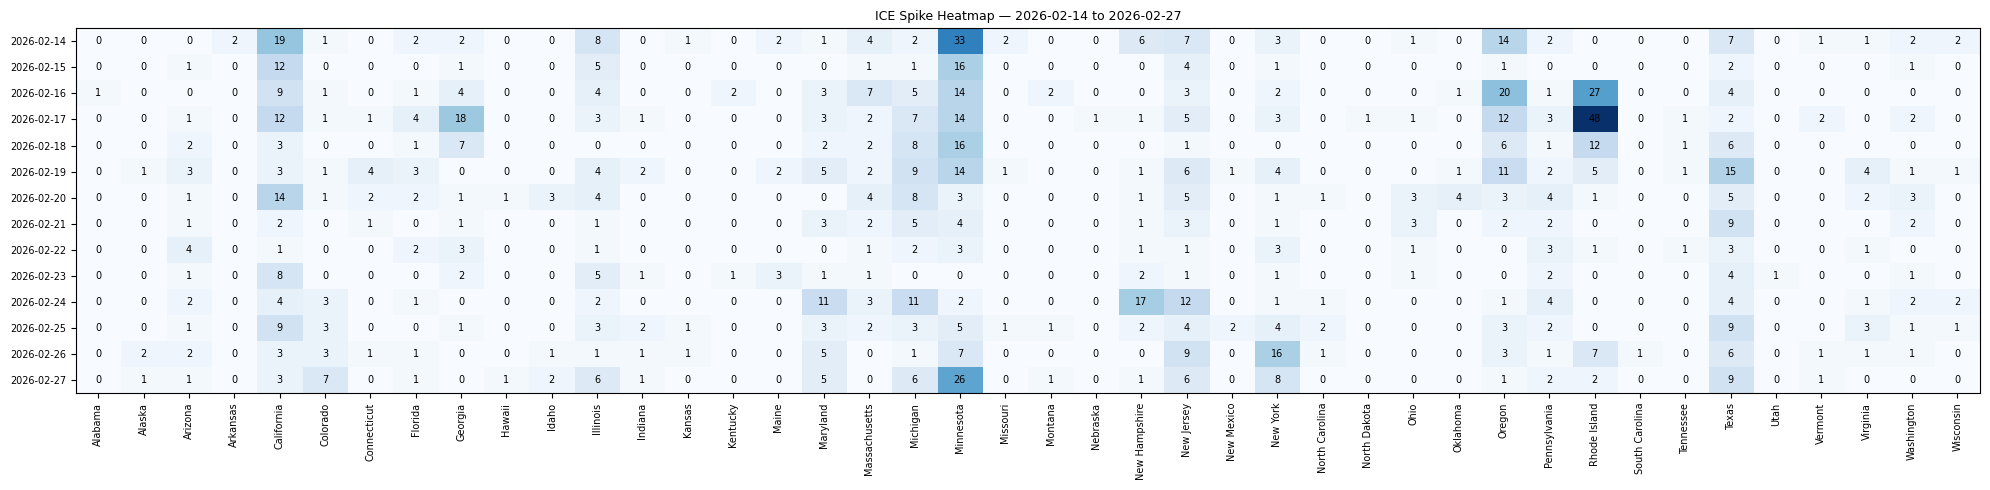

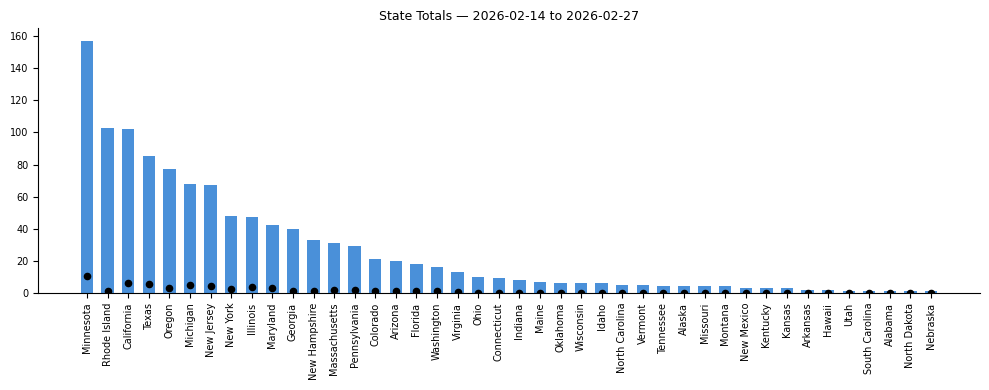

No activity: Delaware, Iowa, Louisiana, Mississippi, Nevada, South Dakota, Wyoming

Date Window: 2026-02-28 — 2026-03-13


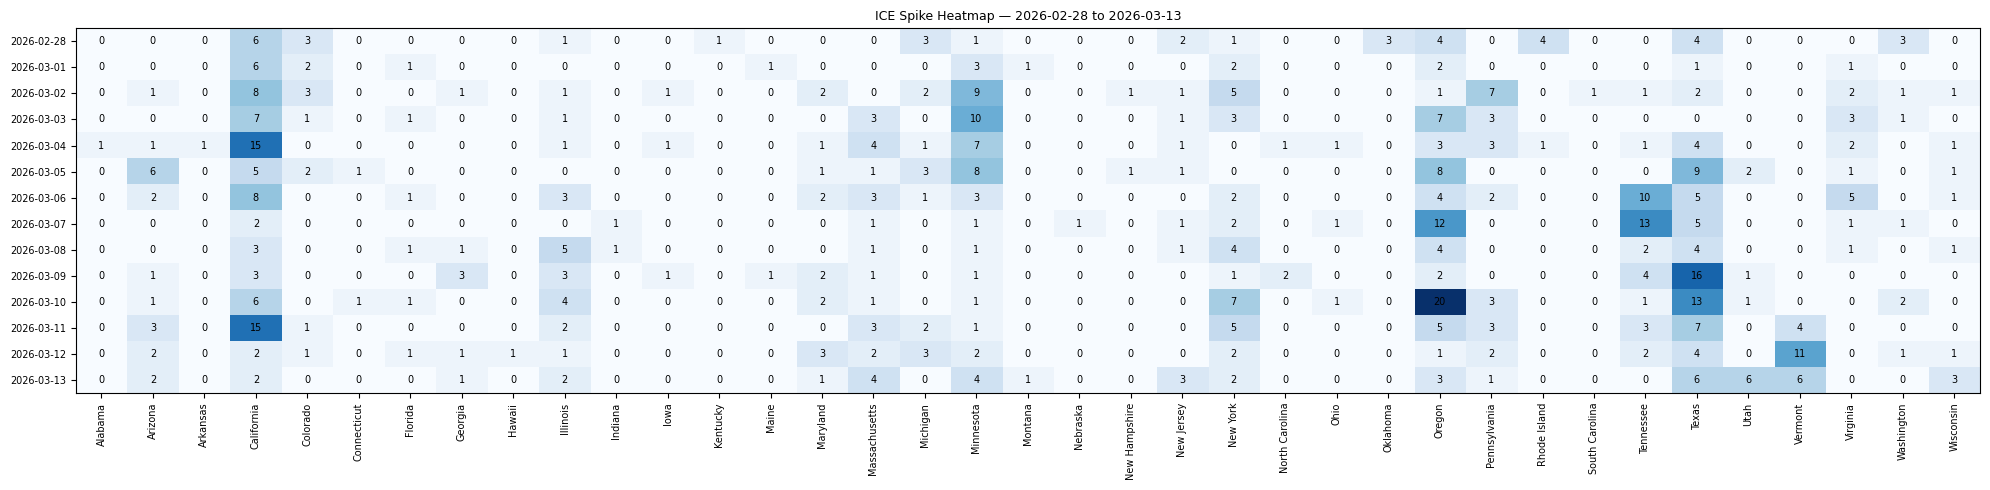

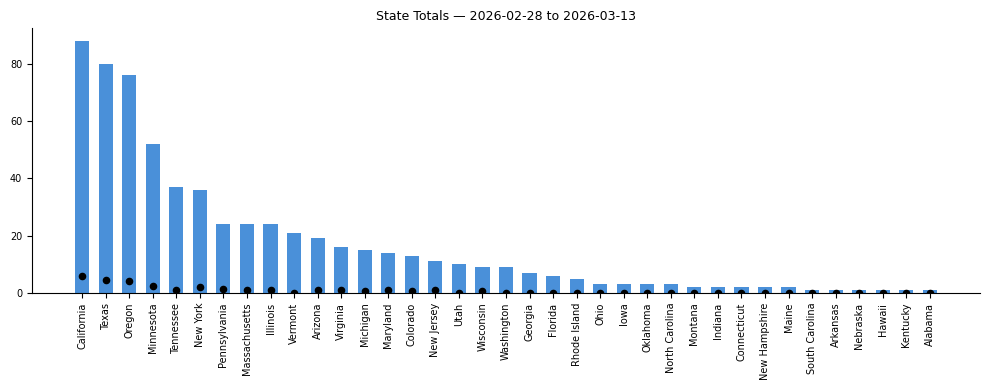

No activity: Alaska, Delaware, Idaho, Kansas, Louisiana, Mississippi, Missouri, Nevada, New Mexico, North Dakota, South Dakota, Wyoming

Date Window: 2026-03-14 — 2026-03-27


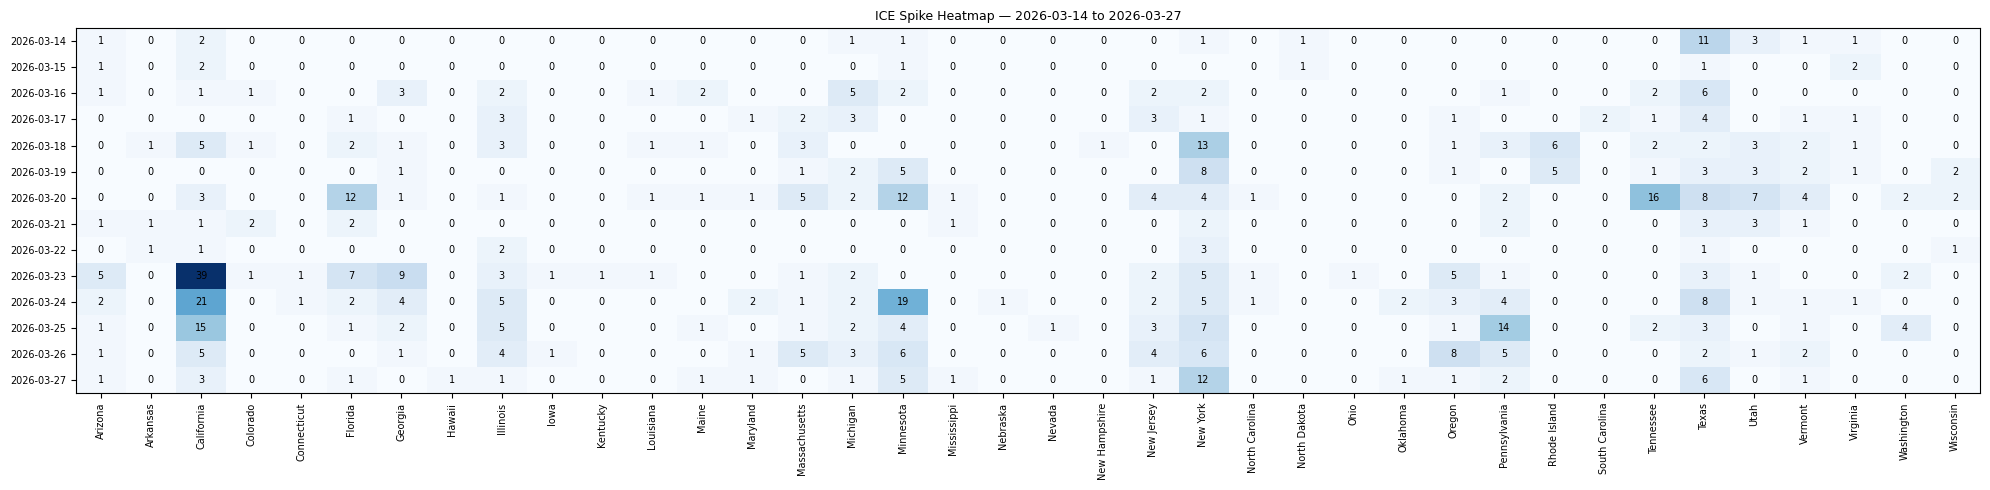

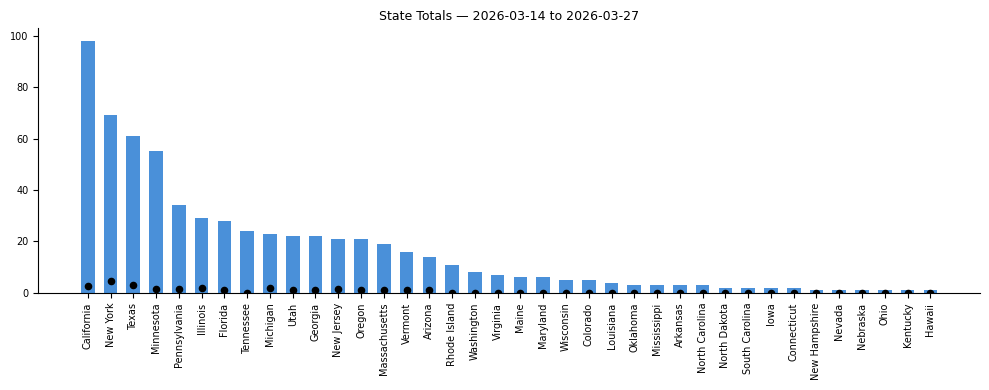

No activity: Alabama, Alaska, Delaware, Idaho, Indiana, Kansas, Missouri, Montana, New Mexico, South Dakota, Wyoming

Date Window: 2026-03-28 — 2026-04-10


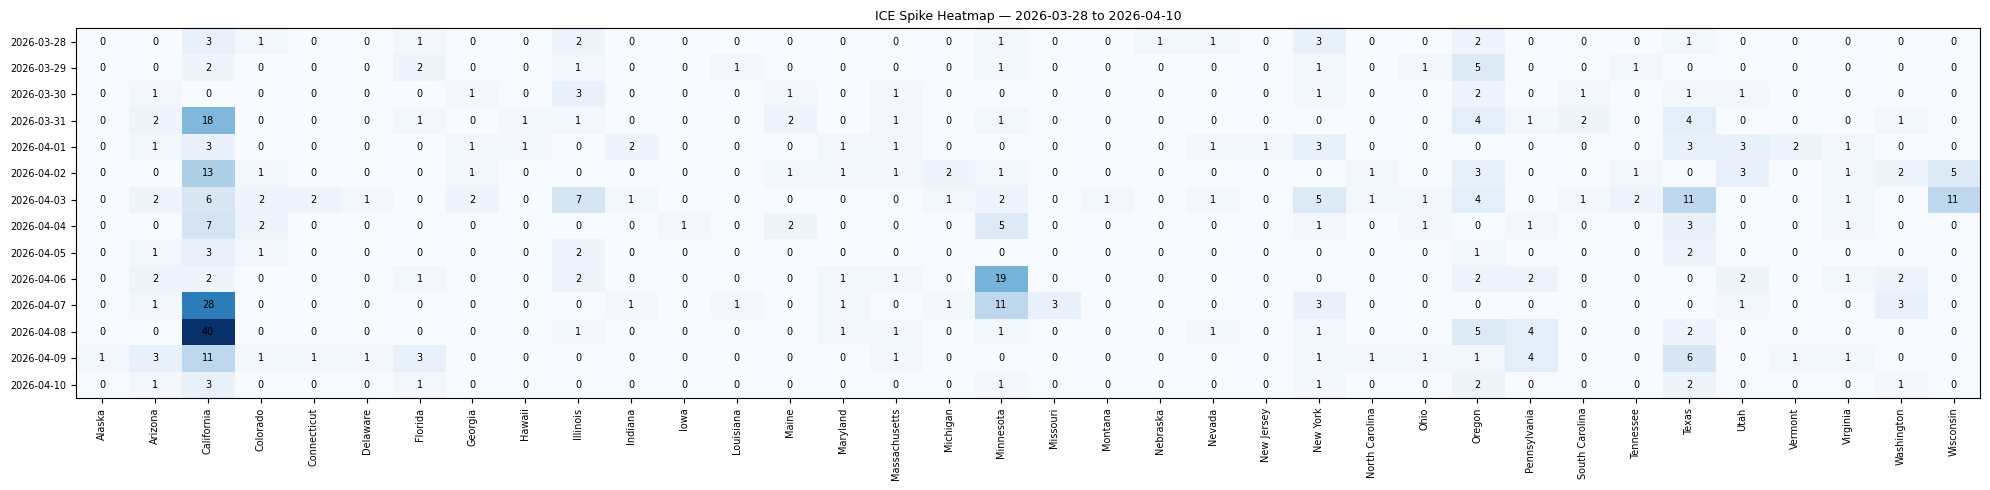

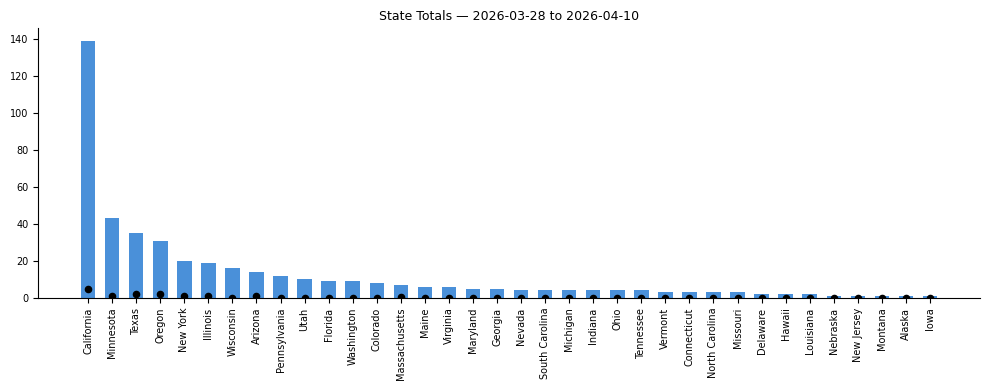

No activity: Alabama, Arkansas, Idaho, Kansas, Kentucky, Mississippi, New Hampshire, New Mexico, North Dakota, Oklahoma, Rhode Island, South Dakota, Wyoming

Date Window: 2026-04-11 — 2026-04-24


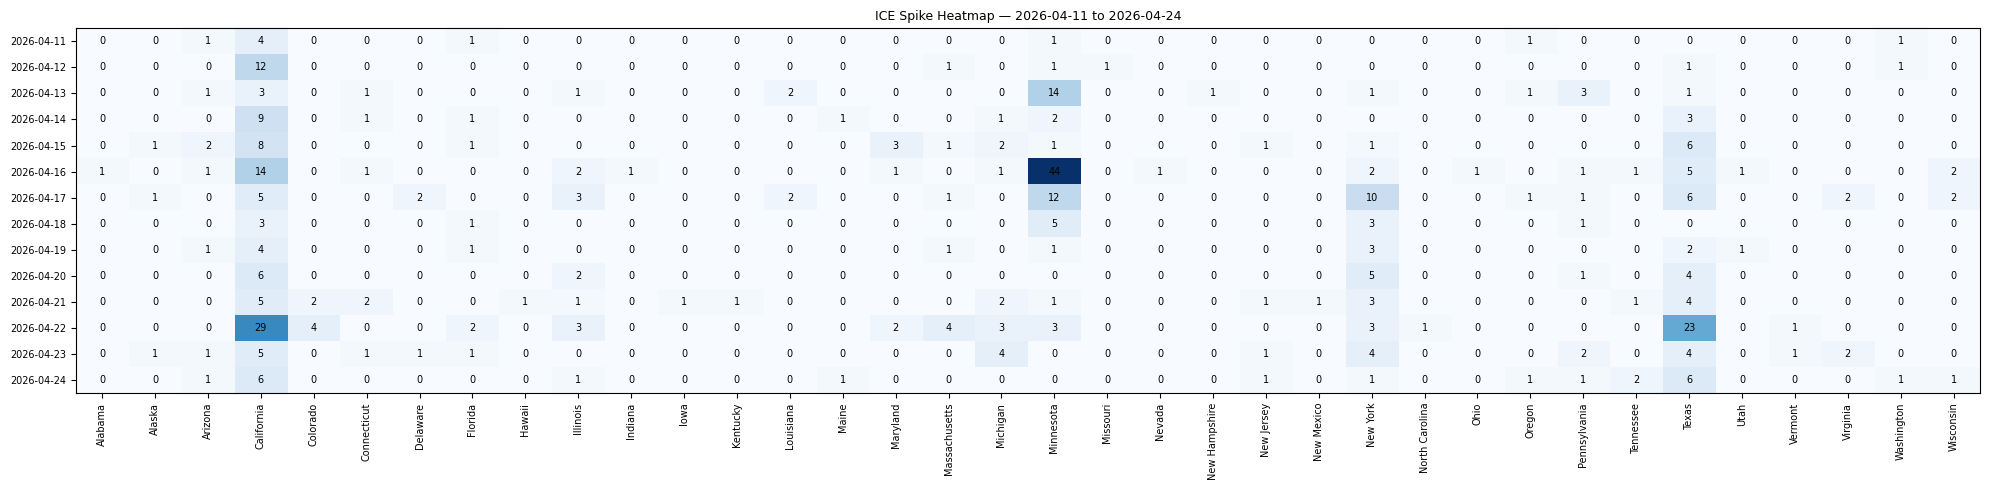

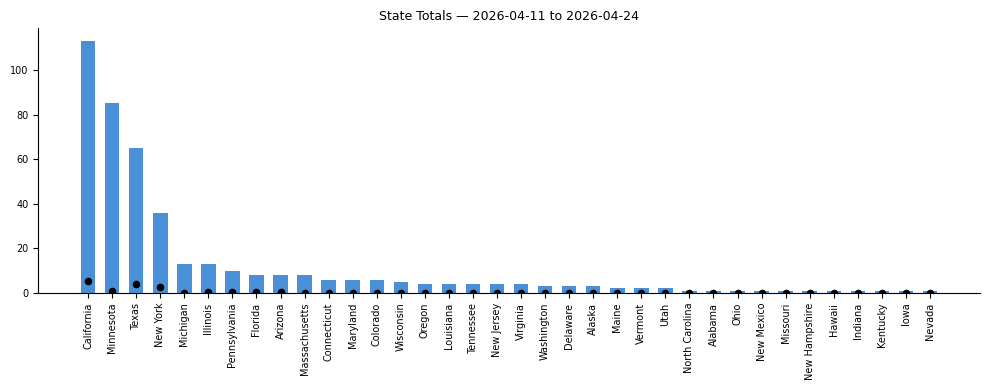

No activity: Arkansas, Georgia, Idaho, Kansas, Mississippi, Montana, Nebraska, North Dakota, Oklahoma, Rhode Island, South Carolina, South Dakota, Wyoming

Date Window: 2026-04-25 — 2026-05-08


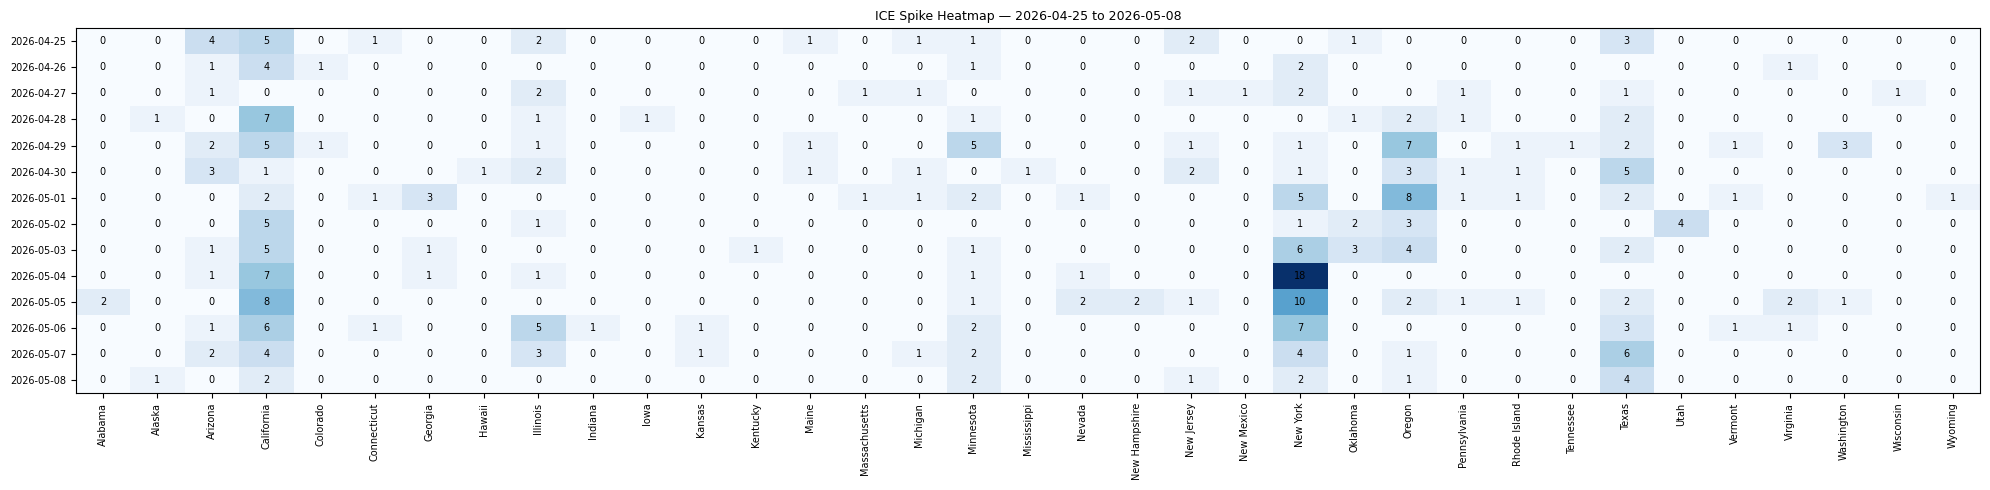

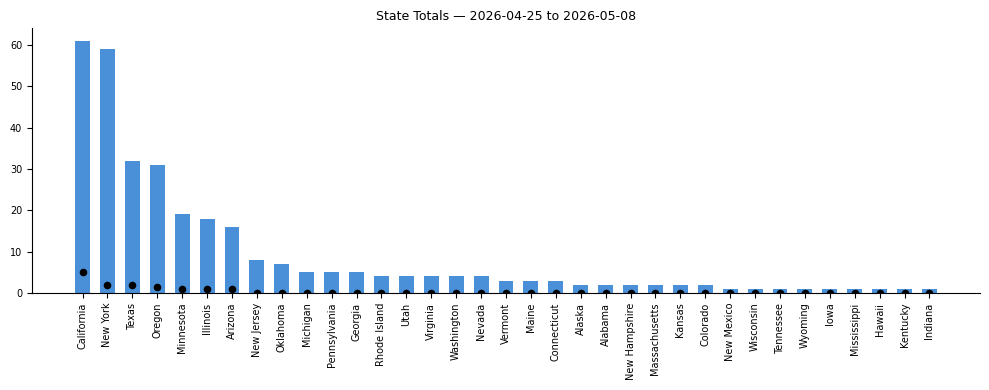

No activity: Arkansas, Delaware, Florida, Idaho, Louisiana, Maryland, Missouri, Montana, Nebraska, North Carolina, North Dakota, Ohio, South Carolina, South Dakota

Date Window: 2026-05-09 — 2026-05-12


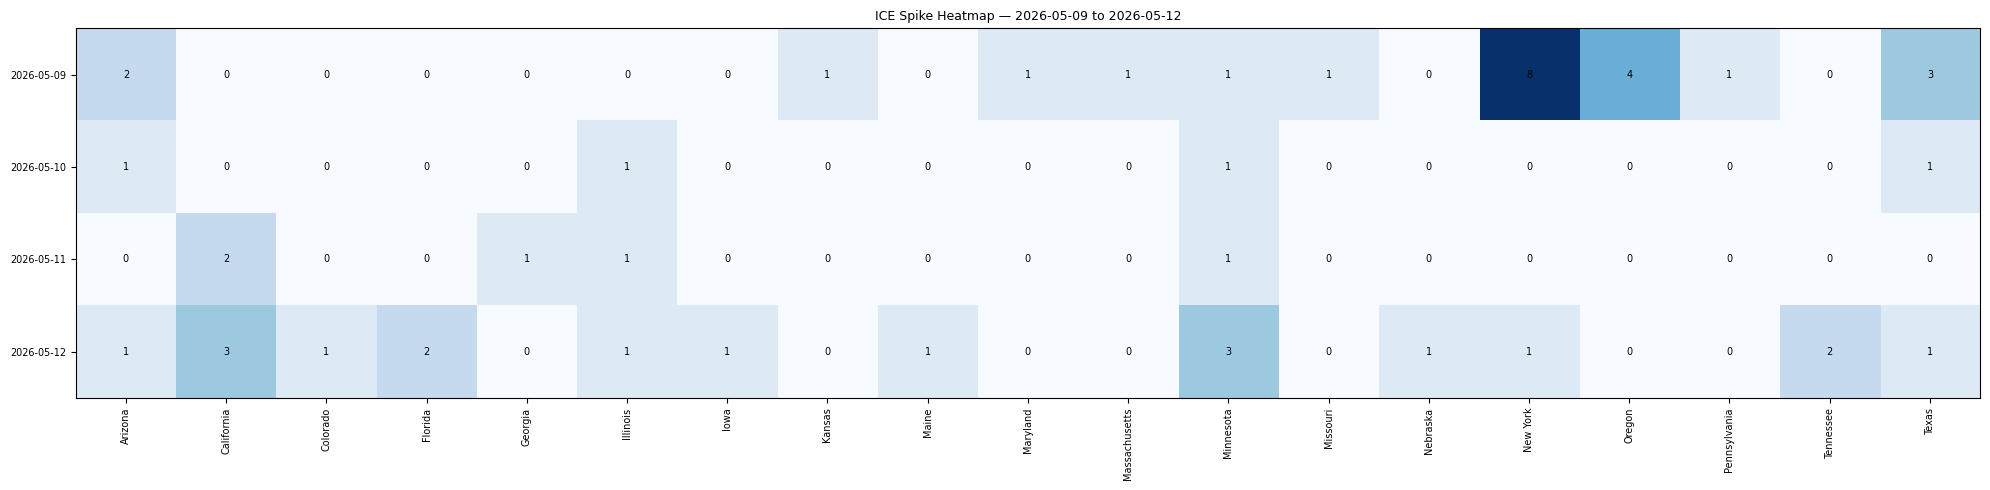

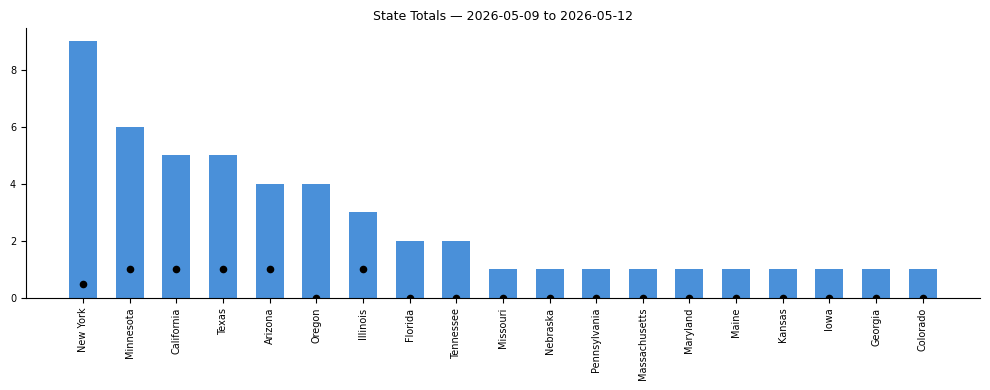

No activity: Alabama, Alaska, Arkansas, Connecticut, Delaware, Hawaii, Idaho, Indiana, Kentucky, Louisiana, Michigan, Mississippi, Montana, Nevada, New Hampshire, New Jersey, New Mexico, North Carolina, North Dakota, Ohio, Oklahoma, Rhode Island, South Carolina, South Dakota, Utah, Vermont, Virginia, Washington, Wisconsin, Wyoming



In [32]:
for i, window_df in enumerate(window_dfs):
    render_slice_report(window_df)
    print()

In [33]:
# this is enough for today; osint is a continuation
# the ML approach was not very useful but I wanted to demonstrate a useful thing
# domain knowledge and skill led to something useful and fast
# there is a lesson in this, and wisdom to be learned. complex isn't "better"; solving problems is "better"